# Serotonin Receptor Expression: mPFC Cell Types and Lateral Habenula (10x snRNA-seq)

Dot plots of 5-HT receptor expression from the Allen Brain Cell Atlas WMB-10X dataset:

- **mPFC** (PL-ILA-ORB): prelimbic, infralimbic, orbital cortex
- **Lateral habenula** (LH Pou4f1 Sox1 Glut subclass from TH region)

### Serotonin Receptors
- **Htr1a** (5-HT1A): Gi-coupled, inhibitory — high in cortical pyramidal neurons
- **Htr2a** (5-HT2A): Gq-coupled, excitatory — enriched in L5 cortical neurons
- **Htr2c** (5-HT2C): Gq-coupled, excitatory — enriched in GABAergic neurons

### Additional Markers
- **Slc17a7** (Vglut1): glutamatergic
- **Gad1, Gad2**: GABAergic
- **Sst, Pvalb, Vip, Lamp5**: interneuron subclass markers
- **Slc6a4** (SERT): serotonin transporter

In [1]:
import pandas as pd
import numpy as np
import re
import os
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Load Pre-extracted Data

In [2]:
def clean_name(x):
    return re.sub(r'^\d+\s+', '', str(x))

# --- mPFC ---
mpfc_expr = pd.read_csv('mpfc_5ht_expression.csv', index_col=0)
mpfc_meta = pd.read_csv('mpfc_5ht_metadata.csv', index_col=0)
mpfc_meta = mpfc_meta.loc[mpfc_expr.index].copy()
mpfc_meta['subclass_short'] = mpfc_meta['subclass'].apply(clean_name)
mpfc_meta['supertype_short'] = mpfc_meta['supertype'].apply(clean_name)
print(f'mPFC: {mpfc_expr.shape[0]:,} cells x {mpfc_expr.shape[1]} genes')

# --- Thalamus (for LHb) ---
th_expr = pd.read_csv('th_5ht_expression.csv', index_col=0)
th_meta = pd.read_csv('th_5ht_metadata.csv', index_col=0)
th_meta = th_meta.loc[th_expr.index].copy()
th_meta['subclass_short'] = th_meta['subclass'].apply(clean_name)
th_meta['supertype_short'] = th_meta['supertype'].apply(clean_name)
print(f'TH:   {th_expr.shape[0]:,} cells x {th_expr.shape[1]} genes')

# Filter to lateral habenula
lhb_mask = th_meta['subclass_short'].str.contains('LH Pou4f1', na=False)
lhb_expr = th_expr.loc[lhb_mask]
lhb_meta = th_meta.loc[lhb_mask].copy()
print(f'LHb:  {lhb_expr.shape[0]:,} cells (lateral habenula glutamatergic)')

target_genes = list(mpfc_expr.columns)
print(f'\nGenes: {target_genes}')

mPFC: 106,122 cells x 11 genes


TH:   261,009 cells x 11 genes
LHb:  2,754 cells (lateral habenula glutamatergic)

Genes: ['Htr1a', 'Htr2a', 'Htr2c', 'Slc17a7', 'Gad1', 'Gad2', 'Sst', 'Pvalb', 'Vip', 'Lamp5', 'Slc6a4']


In [3]:
gene_groups = {
    '5-HT receptors': ['Htr1a', 'Htr2a', 'Htr2c'],
    'NT markers': ['Slc17a7', 'Gad1', 'Gad2'],
    'IN markers': ['Sst', 'Pvalb', 'Vip', 'Lamp5'],
    'SERT': ['Slc6a4'],
}
gene_groups = {k: [g for g in v if g in target_genes] for k, v in gene_groups.items()}
gene_groups = {k: v for k, v in gene_groups.items() if v}

## 2. mPFC Cell Types Overview

In [4]:
sc_counts = mpfc_meta.groupby('subclass_short', observed=True).size().sort_values(ascending=False)
print(f'mPFC (PL-ILA-ORB): {len(mpfc_meta):,} cells, {len(sc_counts)} subclasses')
print(f'\nSubclasses with >= 20 cells:')
for sc_name, cnt in sc_counts.items():
    if cnt >= 20:
        nt = mpfc_meta[mpfc_meta['subclass_short'] == sc_name]['neurotransmitter'].mode()
        nt_str = nt.iloc[0] if len(nt) > 0 else ''
        print(f'  {sc_name}: {cnt:,} ({nt_str})')

mPFC (PL-ILA-ORB): 106,122 cells, 65 subclasses

Subclasses with >= 20 cells:
  L6 CT CTX Glut: 21,453 (Glut)
  L4/5 IT CTX Glut: 14,152 (Glut)
  L6 IT CTX Glut: 11,338 (Glut)
  L2/3 IT CTX Glut: 8,869 (Glut)
  Astro-TE NN: 6,109 (Glut)
  Sst Gaba: 5,377 (GABA)
  L5 IT CTX Glut: 4,419 (Glut)
  L5 NP CTX Glut: 3,988 (Glut)
  L5 ET CTX Glut: 3,739 (Glut)
  Vip Gaba: 3,277 (GABA)
  Microglia NN: 3,144 ()
  Pvalb Gaba: 2,869 (GABA)
  Oligo NN: 2,824 ()
  Lamp5 Gaba: 2,339 (GABA)
  OPC NN: 2,242 ()
  Endo NN: 1,905 ()
  L6b CTX Glut: 1,586 (Glut)
  Sncg Gaba: 1,450 (GABA)
  IT EP-CLA Glut: 733 (Glut)
  L5/6 IT TPE-ENT Glut: 711 (Glut)
  Peri NN: 459 ()


  CLA-EPd-CTX Car3 Glut: 377 (Glut)
  STR D2 Gaba: 355 (GABA)
  IT AON-TT-DP Glut: 332 (Glut)
  STR D1 Gaba: 312 (GABA)
  Sst Chodl Gaba: 285 (GABA)
  SMC NN: 253 ()
  Pvalb chandelier Gaba: 195 (GABA)
  Lamp5 Lhx6 Gaba: 176 (GABA)
  BAM NN: 134 ()
  VLMC NN: 128 ()
  OB Dopa-Gaba: 78 (GABA)
  HPF CR Glut: 78 (Glut)
  OB-out Frmd7 Gaba: 62 (GABA)
  STR D1 Sema5a Gaba: 61 (GABA)
  OB-in Frmd7 Gaba: 61 (GABA)
  STR-PAL Chst9 Gaba: 58 (GABA)
  OB Meis2 Thsd7b Gaba: 51 (GABA)


## 3. Dot Plot: mPFC — 5-HT Receptors by Subclass

AnnData: 105,979 cells, 38 subclasses


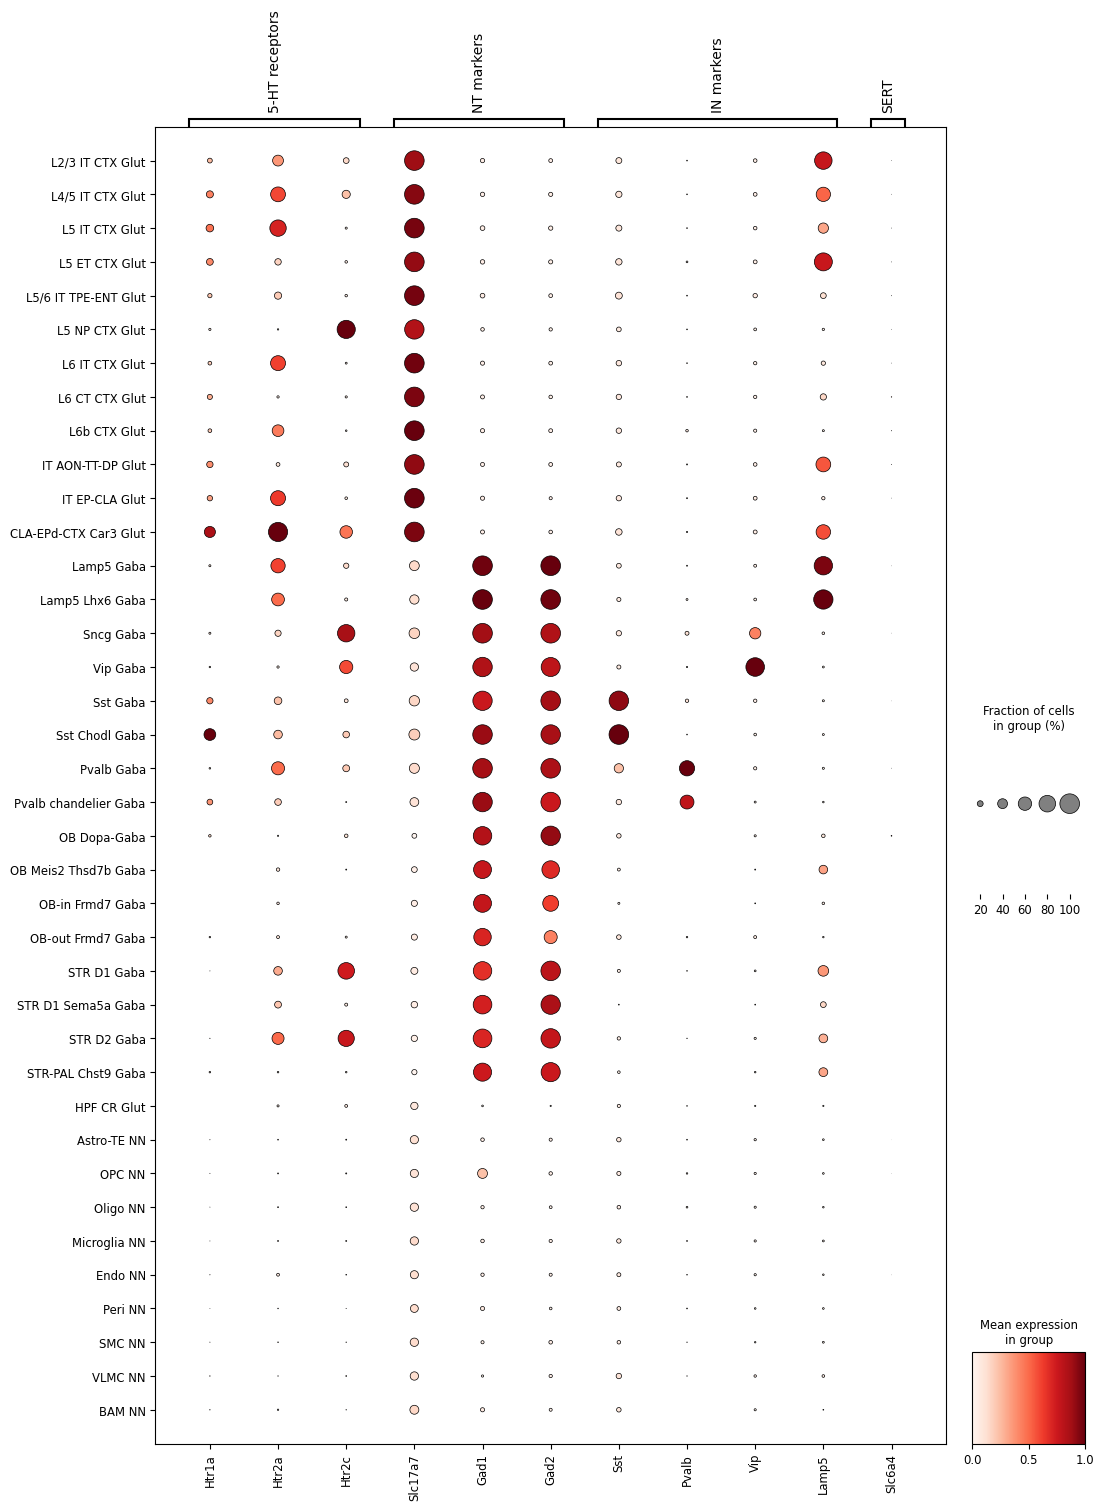

Saved: dotplot_mPFC_5HT_by_subclass.png


In [5]:
def cortical_sort_key(name):
    """Sort cortical subclasses: excitatory layers > interneurons > glia."""
    if 'L2/3' in name or 'L2' in name: return (0, name)
    elif 'L4' in name: return (1, name)
    elif 'L5 IT' in name: return (2, name)
    elif 'L5 ET' in name: return (3, name)
    elif 'L5/6' in name: return (4, name)
    elif 'L5' in name: return (5, name)
    elif 'L6 IT' in name: return (6, name)
    elif 'L6 CT' in name: return (7, name)
    elif 'L6b' in name or 'L6 b' in name: return (8, name)
    elif 'L6' in name: return (9, name)
    elif 'IT EP' in name or 'IT' in name and 'Glut' in name: return (10, name)
    elif 'NP' in name and 'Glut' in name: return (11, name)
    elif 'CT' in name and 'Glut' in name: return (12, name)
    elif 'Lamp5' in name: return (13, name)
    elif 'Sncg' in name: return (14, name)
    elif 'Vip' in name: return (15, name)
    elif 'Sst' in name and 'Chodl' not in name: return (16, name)
    elif 'Sst Chodl' in name: return (17, name)
    elif 'Pvalb' in name: return (18, name)
    elif 'Gaba' in name: return (19, name)
    elif 'Glut' in name: return (20, name)
    elif 'Astro' in name: return (21, name)
    elif 'OPC' in name: return (22, name)
    elif 'Oligo' in name: return (23, name)
    elif 'Micro' in name: return (24, name)
    elif 'Endo' in name: return (25, name)
    elif 'Peri' in name: return (26, name)
    elif 'SMC' in name: return (27, name)
    elif 'VLMC' in name: return (28, name)
    else: return (29, name)

valid_sc = sc_counts[sc_counts >= 20].index.tolist()
sorted_sc = sorted(valid_sc, key=cortical_sort_key)

mask = mpfc_meta['subclass_short'].isin(valid_sc)
adata_mpfc = anndata.AnnData(
    X=mpfc_expr.loc[mask].values,
    obs=mpfc_meta.loc[mask][['subclass_short', 'neurotransmitter']].copy(),
    var=pd.DataFrame(index=target_genes)
)
adata_mpfc.obs['subclass_short'] = pd.Categorical(
    adata_mpfc.obs['subclass_short'], categories=sorted_sc, ordered=True
)

n_sc = len(sorted_sc)
print(f'AnnData: {adata_mpfc.shape[0]:,} cells, {n_sc} subclasses')

dp = sc.pl.dotplot(
    adata_mpfc,
    var_names=gene_groups,
    groupby='subclass_short',
    standard_scale='var',
    cmap='Reds',
    figsize=(12, max(5, n_sc * 0.45)),
    show=False,
    return_fig=True
)
dp.style(dot_edge_color='black', dot_edge_lw=0.5)
dp.savefig('dotplot_mPFC_5HT_by_subclass.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dotplot_mPFC_5HT_by_subclass.png')

## 4. Dot Plot: mPFC — Neuronal Subclasses Only

Neuronal: 88,781 cells, 29 subclasses


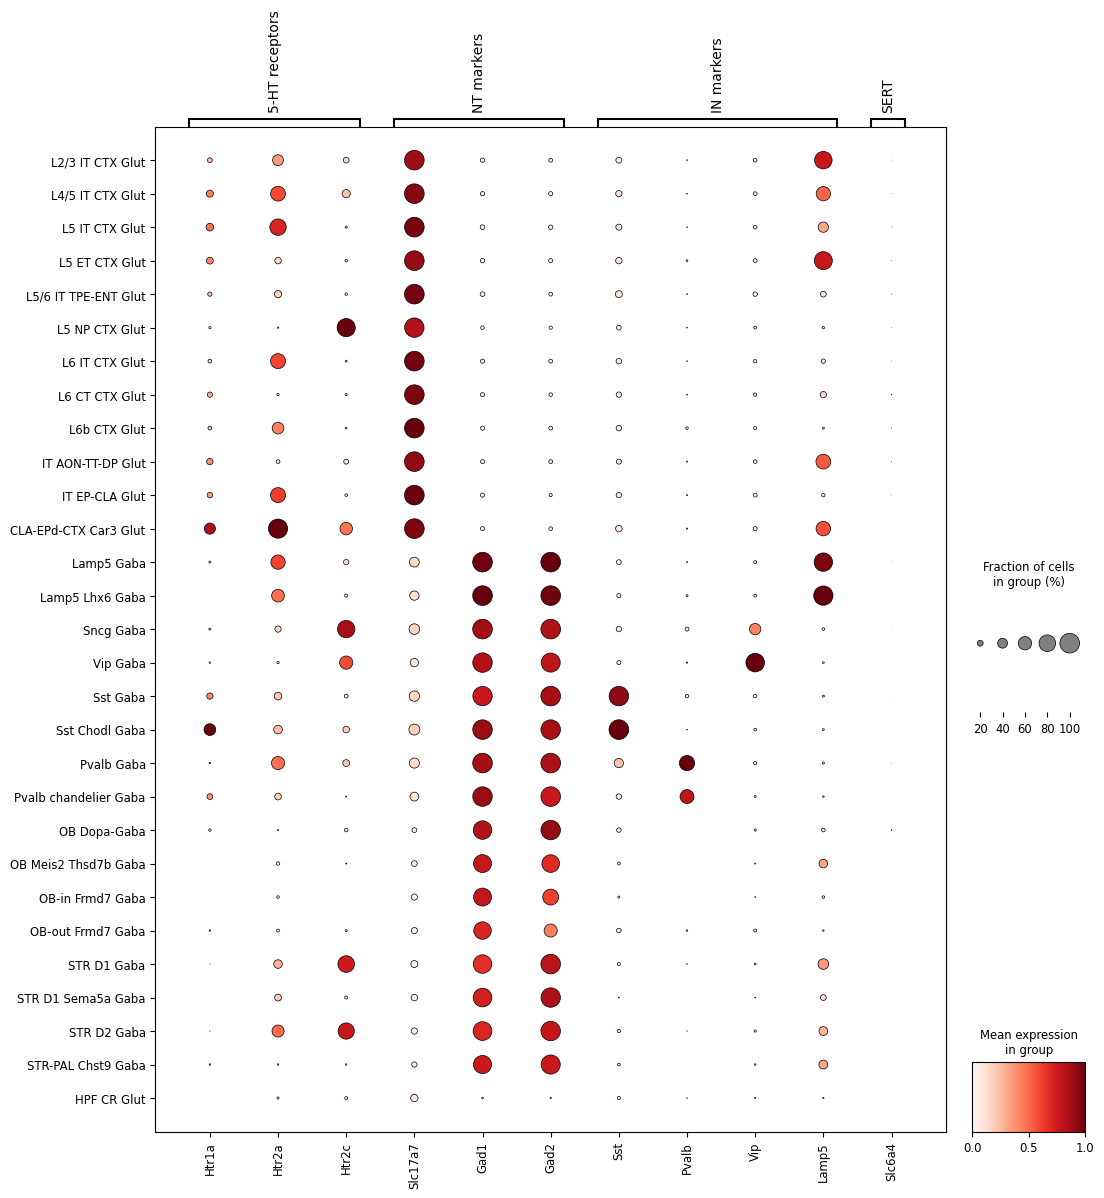

Saved: dotplot_mPFC_5HT_neurons.png


In [6]:
non_neuronal = {'Astro-TE NN', 'Astro-NT NN', 'OPC NN', 'Oligo NN',
                'Microglia NN', 'Endo NN', 'Peri NN', 'SMC NN',
                'VLMC NN', 'Ependymal NN', 'BAM NN', 'CHOR NN'}
neuronal_sc = [s for s in sorted_sc if s not in non_neuronal]

adata_neuron = adata_mpfc[adata_mpfc.obs['subclass_short'].isin(neuronal_sc)].copy()
adata_neuron.obs['subclass_short'] = pd.Categorical(
    adata_neuron.obs['subclass_short'], categories=neuronal_sc, ordered=True
)

n_neuron = len(neuronal_sc)
print(f'Neuronal: {adata_neuron.shape[0]:,} cells, {n_neuron} subclasses')

dp2 = sc.pl.dotplot(
    adata_neuron,
    var_names=gene_groups,
    groupby='subclass_short',
    standard_scale='var',
    cmap='Reds',
    figsize=(12, max(5, n_neuron * 0.45)),
    show=False,
    return_fig=True
)
dp2.style(dot_edge_color='black', dot_edge_lw=0.5)
dp2.savefig('dotplot_mPFC_5HT_neurons.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dotplot_mPFC_5HT_neurons.png')

## 5. Lateral Habenula: 5-HT Receptors by Supertype

In [7]:
print(f'Lateral Habenula (LH Pou4f1 Sox1 Glut): {len(lhb_meta):,} cells')
print(f'\nSupertypes:')
lhb_st_counts = lhb_meta.groupby('supertype_short', observed=True).size().sort_values(ascending=False)
for st, cnt in lhb_st_counts.items():
    print(f'  {st}: {cnt:,}')

# Also show medial habenula for comparison
mhb_mask = th_meta['subclass_short'].str.contains('MH Tac2', na=False)
mhb_expr = th_expr.loc[mhb_mask]
mhb_meta = th_meta.loc[mhb_mask].copy()
print(f'\nMedial Habenula (MH Tac2 Glut): {len(mhb_meta):,} cells (for comparison)')
mhb_st_counts = mhb_meta.groupby('supertype_short', observed=True).size().sort_values(ascending=False)
for st, cnt in mhb_st_counts.items():
    print(f'  {st}: {cnt:,}')

Lateral Habenula (LH Pou4f1 Sox1 Glut): 2,754 cells

Supertypes:
  LH Pou4f1 Sox1 Glut_1: 1,297
  LH Pou4f1 Sox1 Glut_2: 650
  LH Pou4f1 Sox1 Glut_3: 509
  LH Pou4f1 Sox1 Glut_4: 298

Medial Habenula (MH Tac2 Glut): 7,972 cells (for comparison)
  MH Tac2 Glut_3: 4,320
  MH Tac2 Glut_1: 2,312
  MH Tac2 Glut_2: 871
  MH Tac2 Glut_5: 321
  MH Tac2 Glut_4: 148


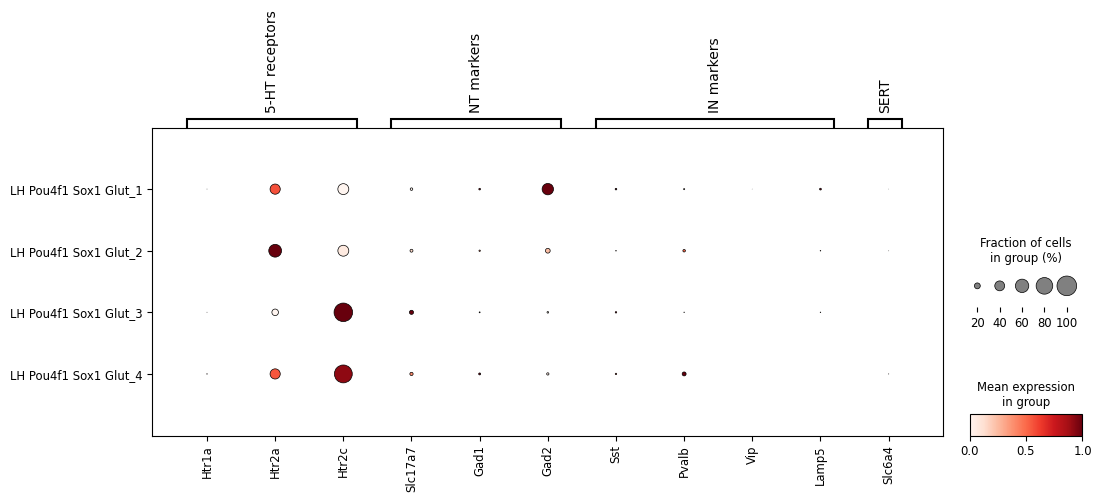

Saved: dotplot_LHb_5HT_by_supertype.png


In [8]:
# Dot plot for LHb supertypes
valid_lhb_st = lhb_st_counts[lhb_st_counts >= 20].index.tolist()

if len(valid_lhb_st) > 0:
    mask_lhb = lhb_meta['supertype_short'].isin(valid_lhb_st)
    adata_lhb = anndata.AnnData(
        X=lhb_expr.loc[mask_lhb].values,
        obs=lhb_meta.loc[mask_lhb][['supertype_short', 'subclass_short']].copy(),
        var=pd.DataFrame(index=target_genes)
    )
    sorted_lhb = sorted(valid_lhb_st)
    adata_lhb.obs['supertype_short'] = pd.Categorical(
        adata_lhb.obs['supertype_short'], categories=sorted_lhb, ordered=True
    )

    dp3 = sc.pl.dotplot(
        adata_lhb,
        var_names=gene_groups,
        groupby='supertype_short',
        standard_scale='var',
        cmap='Reds',
        figsize=(12, max(4, len(sorted_lhb) * 0.6)),
        show=False,
        return_fig=True
    )
    dp3.style(dot_edge_color='black', dot_edge_lw=0.5)
    dp3.savefig('dotplot_LHb_5HT_by_supertype.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: dotplot_LHb_5HT_by_supertype.png')
else:
    print('Not enough LHb supertypes with >= 20 cells for individual dot plot')

## 6. Combined Dot Plot: mPFC Neurons + LHb (Trimmed Mean)

Remove medial habenula, OB, STR, HPF, and non-cortical IT/CLA cell types.
Keep cortical layer IT types (L2/3, L4/5, L5 IT CTX Glut).
Remove broad NT markers (Slc17a7, Gad1, Gad2) — keep 5-HT receptors, interneuron markers, and SERT.
Use trimmed mean (25%-75% IQR) with log2(CPM+1) scale, 0 to >11 range.

Genes for plot: ['Htr1a', 'Htr2a', 'Htr2c', 'Sst', 'Pvalb', 'Vip', 'Lamp5', 'Slc6a4']
Gene groups: {'5-HT receptors': ['Htr1a', 'Htr2a', 'Htr2c'], 'IN markers': ['Sst', 'Pvalb', 'Vip', 'Lamp5'], 'SERT': ['Slc6a4']}
Filtered subclasses: ['L2/3 IT CTX Glut', 'L4/5 IT CTX Glut', 'L5 IT CTX Glut', 'L5 ET CTX Glut', 'L5 NP CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'Lamp5 Gaba', 'Lamp5 Lhx6 Gaba', 'Sncg Gaba', 'Vip Gaba', 'Sst Gaba', 'Sst Chodl Gaba', 'Pvalb Gaba', 'Pvalb chandelier Gaba']


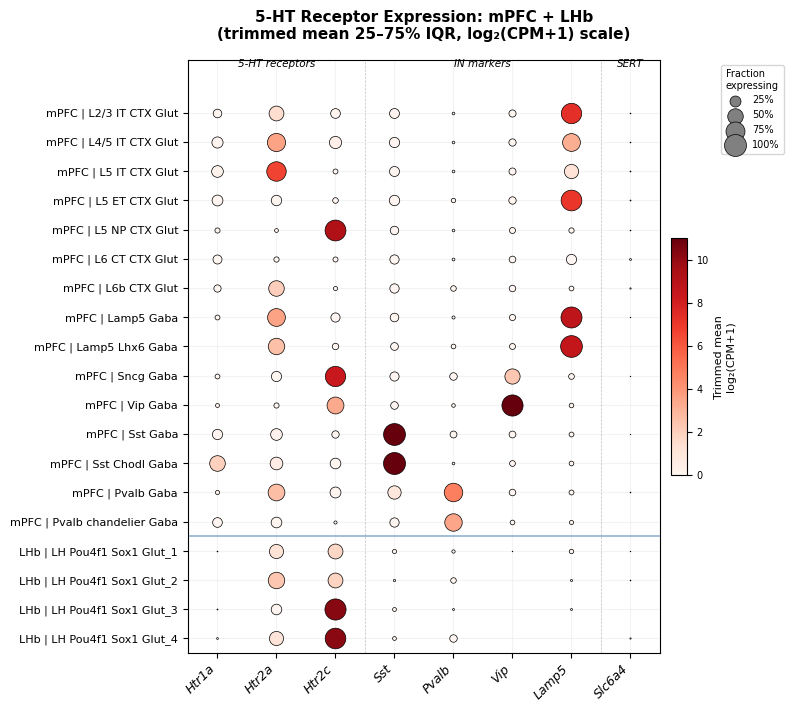

Combined: 76,928 cells, 19 groups
Saved: dotplot_mPFC_LHb_5HT_combined.png


In [9]:
# Combine mPFC neuronal subclasses with LHb supertypes (no MHb)
# Filter out OB, STR, HPF cell types, and remove most IT/CLA cell types
# Keep cortical layer IT types (L2/3, L4/5, L5 IT CTX Glut)
import re as _re
remove_prefixes = ('OB ', 'OB-', 'STR ', 'STR-', 'HPF ')
keep_it = {'L2/3 IT CTX Glut', 'L4/5 IT CTX Glut', 'L5 IT CTX Glut'}
neuronal_sc_filtered = [s for s in neuronal_sc
                        if not any(s.startswith(p) for p in remove_prefixes)
                        and (s in keep_it
                             or (not _re.search(r'\bIT\b', s) and 'CLA' not in s))]

# Remove broad NT markers (Slc17a7, Gad1, Gad2)
remove_genes = {'Slc17a7', 'Gad1', 'Gad2'}
plot_genes = [g for g in target_genes if g not in remove_genes]

# Update gene groups for this plot
plot_gene_groups = {}
for k, v in gene_groups.items():
    filtered = [g for g in v if g not in remove_genes]
    if filtered:
        plot_gene_groups[k] = filtered

print(f'Genes for plot: {plot_genes}')
print(f'Gene groups: {plot_gene_groups}')
print(f'Filtered subclasses: {neuronal_sc_filtered}')

frames_expr = []
frames_meta = []

# mPFC neuronal subclasses (filtered)
mpfc_neuronal_mask = mpfc_meta['subclass_short'].isin(neuronal_sc_filtered)
mpfc_sub = mpfc_meta.loc[mpfc_neuronal_mask].copy()
mpfc_sub['group'] = 'mPFC | ' + mpfc_sub['subclass_short']
frames_expr.append(mpfc_expr.loc[mpfc_neuronal_mask])
frames_meta.append(mpfc_sub)

# LHb supertypes only (no MHb)
lhb_sub = lhb_meta.copy()
lhb_sub['group'] = 'LHb | ' + lhb_sub['supertype_short']
frames_expr.append(lhb_expr)
frames_meta.append(lhb_sub)

combined_expr = pd.concat(frames_expr)
combined_meta = pd.concat(frames_meta)

# Filter to groups >= 20 cells
grp_counts = combined_meta.groupby('group', observed=True).size()
valid_groups = grp_counts[grp_counts >= 20].index.tolist()

# Sort: mPFC first (cortical sort), then LHb
def combined_sort_key(name):
    if name.startswith('mPFC'):
        sc_name = name.split(' | ', 1)[1]
        return (0, cortical_sort_key(sc_name))
    elif name.startswith('LHb'):
        return (1, (0, name))
    else:
        return (2, (0, name))

sorted_groups = sorted(valid_groups, key=combined_sort_key)

# Compute trimmed mean (25%-75% IQR) and fraction expressing per group
def trimmed_mean(arr):
    """Mean of values between 25th and 75th percentiles."""
    if len(arr) == 0:
        return 0.0
    q25, q75 = np.percentile(arr, [25, 75])
    mask = (arr >= q25) & (arr <= q75)
    trimmed = arr[mask]
    return trimmed.mean() if len(trimmed) > 0 else arr.mean()

mask_valid = combined_meta['group'].isin(valid_groups)
expr_valid = combined_expr.loc[mask_valid]
meta_valid = combined_meta.loc[mask_valid]

# Compute stats per group (only for plot_genes)
tmean_rows = []
frac_rows = []
for grp in sorted_groups:
    grp_mask = meta_valid['group'] == grp
    grp_expr = expr_valid.loc[grp_mask]
    tmeans = {}
    fracs = {}
    for g in plot_genes:
        vals = grp_expr[g].values
        tmeans[g] = trimmed_mean(vals)
        fracs[g] = (vals > 0).mean()
    tmean_rows.append(tmeans)
    frac_rows.append(fracs)

grp_tmean = pd.DataFrame(tmean_rows, index=sorted_groups)
grp_frac = pd.DataFrame(frac_rows, index=sorted_groups)

# Custom dot plot
n_grp = len(sorted_groups)
n_genes = len(plot_genes)

fig, ax = plt.subplots(figsize=(8, max(5, n_grp * 0.38)))

# Color: trimmed mean on log2(CPM+1) scale, 0 to 11
vmin, vmax = 0, 11
cmap = plt.cm.Reds
norm = plt.Normalize(vmin=vmin, vmax=vmax)

max_dot = 250
for i, grp in enumerate(sorted_groups):
    for j, gene in enumerate(plot_genes):
        frac = grp_frac.loc[grp, gene]
        tmean = grp_tmean.loc[grp, gene]
        if frac > 0:
            size = frac * max_dot
            color = cmap(norm(tmean))
            ax.scatter(j, n_grp - 1 - i, s=size, c=[color],
                      edgecolors='black', linewidths=0.5, zorder=3)

# Add gene group separators and top labels with proper spacing
pos = 0
for gname, genes in plot_gene_groups.items():
    start = pos
    end = pos + len(genes) - 1
    mid = (start + end) / 2
    ax.text(mid, n_grp + 0.5, gname, ha='center', va='bottom', fontsize=7.5, fontstyle='italic')
    if start > 0:
        ax.axvline(x=start - 0.5, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    pos += len(genes)

# Add horizontal separator between mPFC and LHb
mpfc_count = sum(1 for g in sorted_groups if g.startswith('mPFC'))
if mpfc_count < n_grp:
    sep_y = n_grp - mpfc_count - 0.5
    ax.axhline(y=sep_y, color='steelblue', linewidth=1.2, linestyle='-', alpha=0.6)

ax.set_xticks(range(n_genes))
ax.set_xticklabels(plot_genes, rotation=45, ha='right', fontsize=9, fontstyle='italic')
ax.set_yticks(range(n_grp))
ax.set_yticklabels(reversed(sorted_groups), fontsize=8)
ax.set_xlim(-0.5, n_genes - 0.5)
ax.set_ylim(-0.5, n_grp + 0.8)
ax.grid(True, alpha=0.15)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02, aspect=15)
cbar.set_label('Trimmed mean\nlog₂(CPM+1)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# Size legend
for frac_val in [0.25, 0.5, 0.75, 1.0]:
    ax.scatter([], [], s=frac_val * max_dot, c='gray', edgecolors='black',
              linewidths=0.5, label=f'{frac_val:.0%}')
ax.legend(title='Fraction\nexpressing', loc='upper left', bbox_to_anchor=(1.12, 1.0),
         frameon=True, fontsize=7, title_fontsize=7)

ax.set_title('5-HT Receptor Expression: mPFC + LHb\n(trimmed mean 25–75% IQR, log₂(CPM+1) scale)',
            fontweight='bold', fontsize=11, pad=15)
plt.tight_layout()
plt.savefig('dotplot_mPFC_LHb_5HT_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Combined: {mask_valid.sum():,} cells, {n_grp} groups')
print('Saved: dotplot_mPFC_LHb_5HT_combined.png')

## 7. Heatmap: Mean Expression and Fraction Expressing

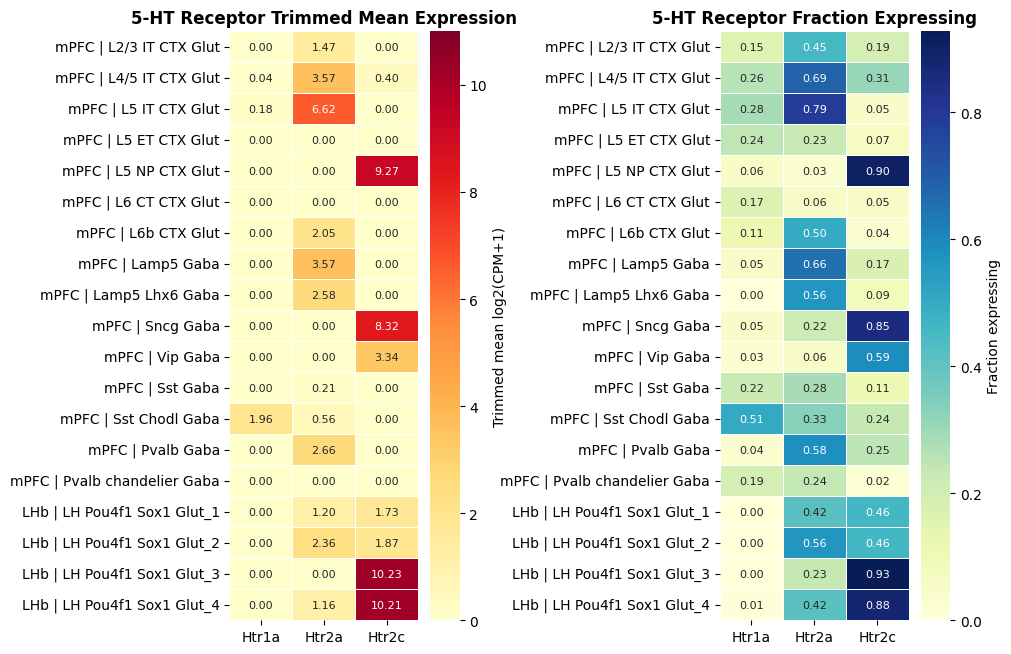

Saved: heatmap_mPFC_LHb_5HT_receptors.png


In [10]:
# Compute per-group stats using trimmed mean (from cell-15)
# Focus on 5-HT receptors
ht_genes = [g for g in ['Htr1a', 'Htr2a', 'Htr2c'] if g in target_genes]

fig, axes = plt.subplots(1, 2, figsize=(10, max(6, n_grp * 0.35)))

sns.heatmap(grp_tmean[ht_genes], annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Trimmed mean log2(CPM+1)'},
            annot_kws={'size': 8}, vmin=0, vmax=11)
axes[0].set_title('5-HT Receptor Trimmed Mean Expression', fontweight='bold')
axes[0].set_ylabel('')

sns.heatmap(grp_frac[ht_genes], annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Fraction expressing'},
            annot_kws={'size': 8})
axes[1].set_title('5-HT Receptor Fraction Expressing', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_mPFC_LHb_5HT_receptors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_mPFC_LHb_5HT_receptors.png')

## 8. Summary Statistics

In [11]:
print('5-HT Receptor Expression Summary (Trimmed Mean 25%-75% IQR)')
print('=' * 80)

# mPFC summary
print(f'\n--- mPFC (PL-ILA-ORB): {len(mpfc_expr):,} cells ---')
for g in ht_genes:
    vals = mpfc_expr[g].values
    print(f'  {g}: trimmed_mean={trimmed_mean(vals):.3f}, frac={(vals > 0).mean():.3f}')

# LHb summary
print(f'\n--- Lateral Habenula (LH Glut): {len(lhb_expr):,} cells ---')
for g in ht_genes:
    vals = lhb_expr[g].values
    print(f'  {g}: trimmed_mean={trimmed_mean(vals):.3f}, frac={(vals > 0).mean():.3f}')

# Full table
print(f'\n{"=" * 80}')
print('Trimmed Mean Expression by Group:')
display(grp_tmean[ht_genes].round(3))

print('\nFraction Expressing by Group:')
display(grp_frac[ht_genes].round(3))

# Save
grp_tmean.to_csv('mpfc_lhb_5ht_mean_expression.csv')
grp_frac.to_csv('mpfc_lhb_5ht_frac_expressing.csv')
print('\nSaved: mpfc_lhb_5ht_mean_expression.csv, mpfc_lhb_5ht_frac_expressing.csv')

5-HT Receptor Expression Summary (Trimmed Mean 25%-75% IQR)

--- mPFC (PL-ILA-ORB): 106,122 cells ---
  Htr1a: trimmed_mean=0.000, frac=0.139
  Htr2a: trimmed_mean=0.597, frac=0.334
  Htr2c: trimmed_mean=0.000, frac=0.171

--- Lateral Habenula (LH Glut): 2,754 cells ---
  Htr1a: trimmed_mean=0.000, frac=0.002
  Htr2a: trimmed_mean=1.190, frac=0.418
  Htr2c: trimmed_mean=3.476, frac=0.590

Trimmed Mean Expression by Group:


,Htr1a,Htr2a,Htr2c
mPFC | L2/3 IT CTX Glut,0.000,1.465,0.000
mPFC | L4/5 IT CTX Glut,0.036,3.572,0.396
mPFC | L5 IT CTX Glut,0.176,6.624,0.000
mPFC | L5 ET CTX Glut,0.000,0.000,0.000
mPFC | L5 NP CTX Glut,0.000,0.000,9.271
mPFC | L6 CT CTX Glut,0.000,0.000,0.000
mPFC | L6b CTX Glut,0.000,2.047,0.000
mPFC | Lamp5 Gaba,0.000,3.572,0.000
mPFC | Lamp5 Lhx6 Gaba,0.000,2.583,0.000
mPFC | Sncg Gaba,0.000,0.000,8.322



Fraction Expressing by Group:


,Htr1a,Htr2a,Htr2c
mPFC | L2/3 IT CTX Glut,0.153,0.454,0.195
mPFC | L4/5 IT CTX Glut,0.257,0.686,0.311
mPFC | L5 IT CTX Glut,0.283,0.786,0.051
mPFC | L5 ET CTX Glut,0.243,0.227,0.066
mPFC | L5 NP CTX Glut,0.055,0.030,0.902
mPFC | L6 CT CTX Glut,0.168,0.057,0.053
mPFC | L6b CTX Glut,0.110,0.501,0.036
mPFC | Lamp5 Gaba,0.050,0.655,0.174
mPFC | Lamp5 Lhx6 Gaba,0.000,0.562,0.085
mPFC | Sncg Gaba,0.049,0.217,0.850



Saved: mpfc_lhb_5ht_mean_expression.csv, mpfc_lhb_5ht_frac_expressing.csv
